In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:

x = np.linspace(0, 2*np.pi, 500)
y = np.sin(x) * np.exp(-x / 5)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

In [3]:
L = 10
state = np.random.randint(0,2,(L,L))
print(state)

[[1 1 0 0 1 1 1 0 0 0]
 [0 0 1 0 0 1 0 1 1 0]
 [1 0 1 1 0 0 0 0 0 1]
 [1 1 1 1 1 0 1 0 0 0]
 [1 1 0 0 1 1 1 0 0 0]
 [0 1 0 1 0 0 0 0 1 0]
 [1 0 1 1 0 1 0 1 1 1]
 [0 0 1 0 1 0 1 0 0 0]
 [1 1 0 0 0 0 0 1 1 0]
 [1 1 0 1 0 1 0 1 1 1]]


In [3]:
def random_config(L):
    #return np.random.randint(0,2,(L,L))
    return np.random.choice([-1, 1], (L,L))

In [4]:
def get_neighbors(state, pos):
    L, _ = state.shape
    i, j = pos
    neighbors = np.array([state[((i+1) % L,j % L)], state[((i-1) % L,j % L)], state[(i % L,(j + 1) % L)], state[(i % L,(j - 1) % L)]])
    return neighbors

In [5]:
def H(state, J, h):
    L, _ = state.shape
    energy_h = h * state.sum()
    state_shift_x = np.roll(state, 1, axis=0)
    state_shift_y = np.roll(state, 1, axis=1)

    energy_J_x = np.sum(J * state * state_shift_x)
    energy_J_y = np.sum(J * state * state_shift_y)

    return energy_h + energy_J_x + energy_J_y

def M(state):
    return np.sum(state)


In [6]:
def dH(state, pos, J, h):
    dh = - 2 * h * state[pos] 
    dJ = - 2 * J * state[pos] * np.sum(get_neighbors(state,pos))
    return dh + dJ

In [7]:
def metropolis_step(state,beta, J, h):
    L, _ = state.shape
    pos = tuple(np.random.randint(s) for s in state.shape)#random tuple from 0:L-1
    r = np.random.uniform()
    comp = np.exp(-beta * dH(state, pos, J, h))
    if r < comp:
        state[pos] *= -1
        return state
    else:
        return state


In [18]:
def run_metropolis(L, beta, J, h, N, init_sweeps, sample_interval):
    state = random_config(L)

    for i in range(init_sweeps):
        state = metropolis_step(state, beta, J, h)

    H_arr = np.array([])
    H_var_arr = np.array([])
    M_arr = np.array([])
    M_var_arr = np.array([])

    for i in range(N):
        H_arr = np.append(H_arr, H(state, J, h))
        M_arr = np.append(M_arr, M(state))

        for i in range(sample_interval):
            state = metropolis_step(state, beta, J, h)

    energy = np.mean(H_arr)
    energy_per_site = energy / (state.shape[0] * state.shape[1])

    energy_var = np.var(H_arr) / ((state.shape[0] * state.shape[1])**2)


    mag = np.mean(M_arr)
    mag_per_site = mag / (state.shape[0] * state.shape[1])
    mag_var = np.var(M_arr) / ((state.shape[0] * state.shape[1])**2)

    

    return 1/beta, energy_per_site, energy_var, mag_per_site, mag_var, abs(mag_per_site)



In [17]:
T, e, evar, m, mvar, absm, state = run_metropolis(10, 0.43, -1, 0, 3000, 200000, 1000)

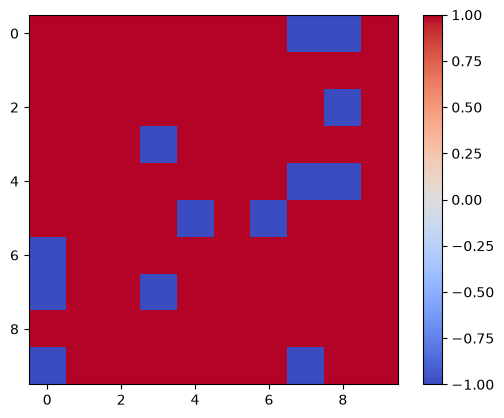

In [10]:
plt.imshow(state, cmap = "coolwarm")
plt.colorbar()
plt.show()

In [25]:
temperatures = [i for i in np.linspace(1,3,20)]
print(temperatures)
L = 10

for i, T in enumerate(temperatures):
    Temp, e, evar, m, mvar, absm = run_metropolis(L, 1/T, -1, 0, 3000, 200000, 1000)

    row = pd.DataFrame([{"Temperature": Temp,
                     "Energy_per_site": e,
                     "Energy_variance": evar,
                     "Magnetization": m,
                     "Magnetization_variance": mvar,
                     "Abs_Magnetization": absm}])

    row.to_csv(
        "results.csv",
        mode = "a",
        header = (i == 0),
        index = False
    )

[np.float64(1.0), np.float64(1.1052631578947367), np.float64(1.2105263157894737), np.float64(1.3157894736842106), np.float64(1.4210526315789473), np.float64(1.526315789473684), np.float64(1.631578947368421), np.float64(1.736842105263158), np.float64(1.8421052631578947), np.float64(1.9473684210526314), np.float64(2.052631578947368), np.float64(2.1578947368421053), np.float64(2.263157894736842), np.float64(2.3684210526315788), np.float64(2.473684210526316), np.float64(2.5789473684210527), np.float64(2.6842105263157894), np.float64(2.789473684210526), np.float64(2.894736842105263), np.float64(3.0)]


In [38]:
df = pd.read_csv("../data/results_h1e-3.csv")

In [39]:
df

,Linear_size,Temperature,Energy_per_site,Energy_variance,Magnetization,Magnetization_variance,Abs_Magnetization
0,10,1.000000,-1.998306,0.000212,-0.999320,0.000014,0.999320
1,10,1.105263,-1.994198,0.000570,-0.998253,0.000040,0.998253
2,10,1.210526,-1.989610,0.000979,-0.997007,0.000073,0.997007
3,10,1.315789,-1.981381,0.001698,-0.994827,0.000132,0.994827
4,10,1.421053,-1.965830,0.003178,-0.990407,0.000274,0.990407
5,10,1.526316,-1.944829,0.004934,0.984793,0.000493,0.984793
6,10,1.631579,-1.916131,0.007842,0.975993,0.000900,0.975993
7,10,1.736842,-1.887953,0.010899,-0.966700,0.001285,0.966700
8,10,1.842105,-1.839150,0.017124,-0.949627,0.002624,0.949627
9,10,1.947368,-1.778621,0.024966,0.245640,0.799822,0.245640


In [40]:
type(df["Temperature"])

pandas.Series

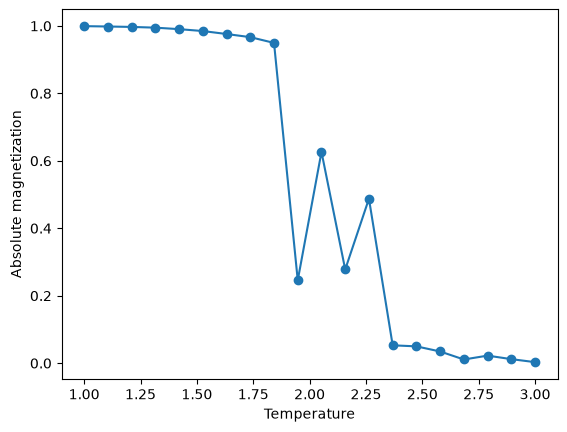

In [41]:
plt.plot(df["Temperature"], df["Abs_Magnetization"], marker = "o")

plt.xlabel("Temperature")
plt.ylabel("Absolute magnetization")
plt.show()

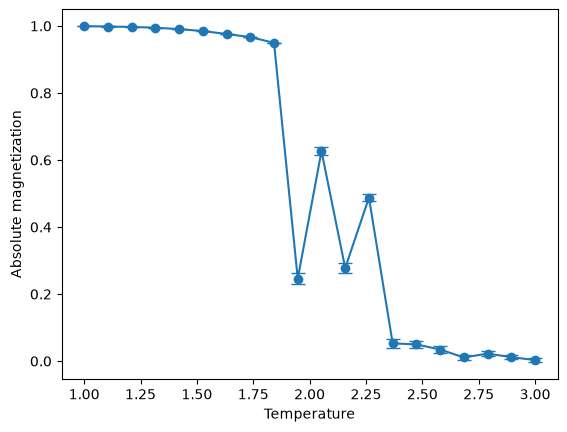

In [42]:
yerr = np.sqrt(df["Magnetization_variance"] / 3000)

plt.errorbar(df["Temperature"], df["Abs_Magnetization"], yerr = yerr,
              marker = "o",
              linestyle = "-", 
              capsize = 5)

plt.xlabel("Temperature")
plt.ylabel("Absolute magnetization")
plt.show()

In [59]:
state = random_config(2)
print(state)

[[-1 -1]
 [-1  1]]


In [40]:
1000000

1000000

In [62]:
state

array([[-1, -1],
       [-1, -1]])

In [61]:
state_new = metropolis_step(state, 1, -1, 0)
print(state_new)

(1, 0)
0.19594895001763846
0.00033546262790251185
[[-1 -1]
 [-1 -1]]


In [39]:
np.exp(dH(state, (0,0), -1, 0))

np.float64(2980.9579870417283)

In [7]:
statetest = np.array([[-1,1],[1,-1]])
print(statetest)

[[-1  1]
 [ 1 -1]]


In [8]:
energy = H(state, -1,0)

[[ 1 -1]
 [ 1 -1]]


In [129]:
print(energy)

8


In [23]:
get_neighbors(state, (2,2))

[np.int32(1), np.int32(1), np.int32(1), np.int32(0)]

In [34]:
s = random_config(L)

In [50]:
s

array([[ 1,  1,  1, -1, -1, -1,  1,  1,  1,  1],
       [ 1,  1,  1,  1,  1,  1, -1,  1,  1, -1],
       [ 1, -1, -1, -1,  1, -1, -1,  1,  1, -1],
       [-1,  1, -1, -1, -1,  1,  1,  1, -1,  1],
       [ 1,  1,  1, -1,  1,  1, -1,  1, -1,  1],
       [-1,  1,  1,  1,  1,  1, -1,  1,  1,  1],
       [-1, -1, -1,  1, -1, -1, -1, -1, -1,  1],
       [-1, -1,  1,  1, -1,  1,  1,  1, -1,  1],
       [-1,  1, -1,  1,  1,  1,  1, -1,  1,  1],
       [-1,  1,  1, -1, -1,  1,  1, -1, -1,  1]])

In [55]:
s_new = np.roll(s, shift=(1, 1), axis=(0, 1))

In [56]:
s_new

array([[ 1, -1,  1,  1, -1, -1,  1,  1, -1, -1],
       [ 1,  1,  1,  1, -1, -1, -1,  1,  1,  1],
       [-1,  1,  1,  1,  1,  1,  1, -1,  1,  1],
       [-1,  1, -1, -1, -1,  1, -1, -1,  1,  1],
       [ 1, -1,  1, -1, -1, -1,  1,  1,  1, -1],
       [ 1,  1,  1,  1, -1,  1,  1, -1,  1, -1],
       [ 1, -1,  1,  1,  1,  1,  1, -1,  1,  1],
       [ 1, -1, -1, -1,  1, -1, -1, -1, -1, -1],
       [ 1, -1, -1,  1,  1, -1,  1,  1,  1, -1],
       [ 1, -1,  1, -1,  1,  1,  1,  1, -1,  1]])

In [15]:
b,c = a

In [16]:
b

2

In [59]:
s.sum()

np.int64(18)

In [63]:
5 * np.sum(s)

np.int64(90)